In [1]:
import re
import ast
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid", palette="deep")

In [2]:
ds = load_dataset("LabARSS/MMLU-Pro-reasoning-entropy-Qwen3-8B")
df = pd.DataFrame(ds["train"])
df.head()

,answer,answer_index,base_cluster,category,cot_content,meta_cluster,options,question,question_id,qwen_8b_ans_correct,...,qwen_8b_answer_embeddings,qwen_8b_entropies,qwen_8b_every_token_info,qwen_8b_extracted_answer_text,qwen_8b_input_embeddings,qwen_8b_response,qwen_8b_think_embeddings,src,total_tokens,__index_level_0__
0,C,2,Legal Theory Interpretations,law,None,Legal Interpretation,[There is no distinction between the two forms...,Which of the following criticisms of Llewellyn...,1286,True,...,"{""min"": [1.1953125, 0.359375, 0.6796875, -0.41...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",3,"{""min"": [-1.8671875, -4.375, -3.015625, -2.312...","<think>\nOkay, let's tackle this question. The...","{""min"": [-2.6875, -4.03125, -5.125, -4.40625, ...",ori_mmlu-jurisprudence,81,0
1,E,4,Constitutional Law,law,None,Legal Interpretation,"[Article 19, Article 11, Article 12, Article 9...",Which of the following articles are not qualif...,1293,True,...,"{""min"": [1.0546875, 0.423828125, 0.57421875, -...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.7254042...","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",5,"{""min"": [-1.65625, -4.0, -2.984375, -3.765625,...","<think>\nOkay, let's tackle this question. The...","{""min"": [-4.78125, -4.03125, -4.0625, -6.34375...",ori_mmlu-international_law,38,1
2,D,3,Business & Marketing Queries,business,None,Economics & Finance MCQs,"[Work delegation, Workload balancing, Work dis...",As what is ensuring that one individual does n...,83,False,...,"{""min"": [1.140625, 0.353515625, 0.65234375, -0...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",2,"{""min"": [-1.78125, -5.53125, -3.390625, -2.437...","<think>\nOkay, let's tackle this question. The...","{""min"": [-1.625, -4.125, -3.015625, -2.5625, -...",ori_mmlu-management,49,2
3,J,9,Business Finance Questions,business,None,Economics & Finance MCQs,"[$308.25, $142.75, $199.99, $225.85, $113.52, ...",Margaret Denault recently rented a truck to dr...,94,False,...,,"[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",None,"{""min"": [-2.046875, -5.625, -3.03125, -2.34375...","<think>\nOkay, let's see. Margaret rented a tr...",,stemez-Business,118,3
4,I,8,Business Finance Questions,business,None,Economics & Finance MCQs,"[$60,000, $43,200, $1,794, $25,000, $30,000, $...",The tax rate in the town of Centerville is 11(...,104,True,...,"{""min"": [1.03125, -0.0198974609375, 0.75390625...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",9,"{""min"": [-1.671875, -4.53125, -3.421875, -3.40...","<think>\nOkay, let's see. The question is abou...","{""min"": [-2.78125, -4.03125, -4.40625, -3.7031...",stemez-Business,102,4


In [3]:
def extract_response_index(text):
    parts = text.split("</think>")
    if len(parts) != 2:
        return None
    match = re.findall(r"[1-9]", parts[1])
    return int(match[-1]) - 1 if match else None

In [4]:
df['response_index'] = df['qwen_8b_response'].apply(extract_response_index)
df = df.dropna(subset=['response_index']).reset_index(drop=True)
df['is_correct'] = df['answer_index'] == df['response_index']
print("Accuracy:", df['is_correct'].mean())

Accuracy: 0.7007434944237918


In [5]:
token_info_col = df['qwen_8b_every_token_info']

token_infos = list()
for x in tqdm(token_info_col):
    token_infos.append(ast.literal_eval(x))


00%|█████████████████████████████████████| 10222/10222 [04:23<00:00, 38.74it/s]

In [6]:
def compute_step_stats(step):
    probs = np.array([t['token_prob'] for t in step])
    ent = -np.sum(probs * np.log(probs + 1e-12))
    if len(probs) > 1:
        sorted_p = np.sort(probs)[::-1]
        marg = sorted_p[0] - sorted_p[1]
    else:
        marg = 0.0
    return ent, marg

In [7]:
entropy_lists = []
margin_lists = []
for info in token_infos:
    ents, mars = zip(*(compute_step_stats(step) for step in info))
    entropy_lists.append(ents)
    margin_lists.append(mars)

In [8]:
df['step_entropies'] = entropy_lists
df['step_margins'] = margin_lists

In [9]:
df['mean_entropy'] = df['step_entropies'].apply(np.mean)
df['max_entropy'] = df['step_entropies'].apply(np.max)
df['mean_margin'] = df['step_margins'].apply(np.mean)
df['max_margin'] = df['step_margins'].apply(np.max)

In [10]:
THINK_ID = 151668
SPECIAL_THRESH = 151642

In [11]:
def thinking_answer_entropy(info, ents):
    gen_ids = [max(step, key=lambda x: x['token_prob'])['token_idx'] for step in info]
    if gen_ids.count(THINK_ID) != 1:
        return np.nan, np.nan
    split = gen_ids.index(THINK_ID)
    
    think_idxs = [i for i in range(split) if gen_ids[i] <= SPECIAL_THRESH]
    ans_idxs   = [i for i in range(split+1, len(gen_ids)) if gen_ids[i] <= SPECIAL_THRESH]
    think_ent = np.sum([ents[i] for i in think_idxs])
    ans_ent   = np.sum([ents[i] for i in ans_idxs])
    return think_ent, ans_ent

In [12]:
think_ans = [thinking_answer_entropy(info, ents)
             for info, ents in zip(token_infos, entropy_lists)]

In [13]:
df['thinking_entropy'], df['answer_entropy'] = zip(*think_ans)

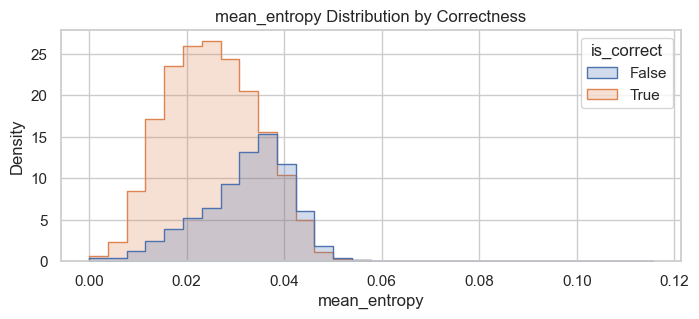

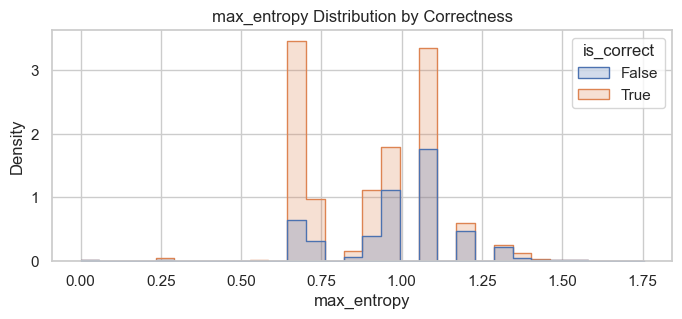

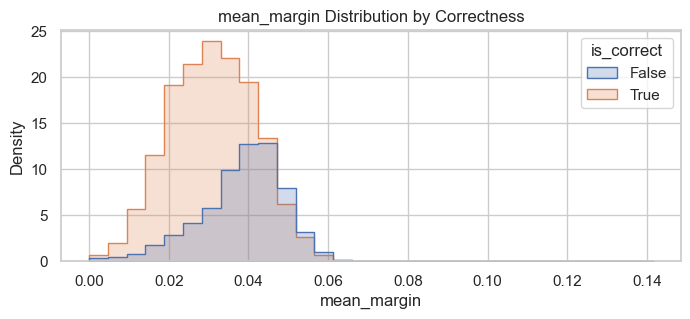

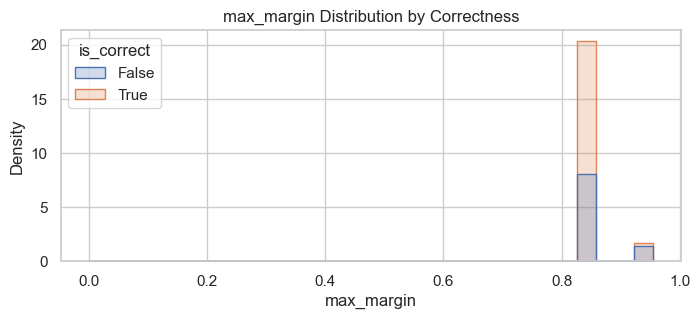

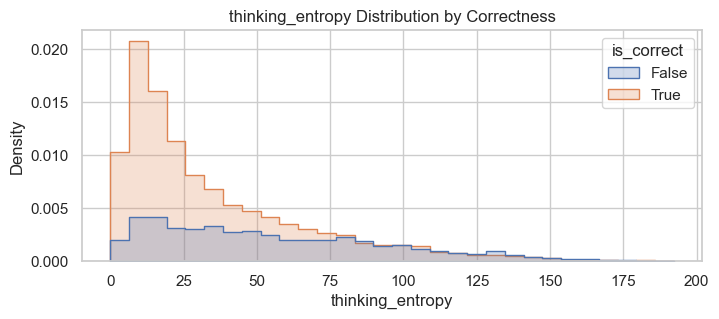

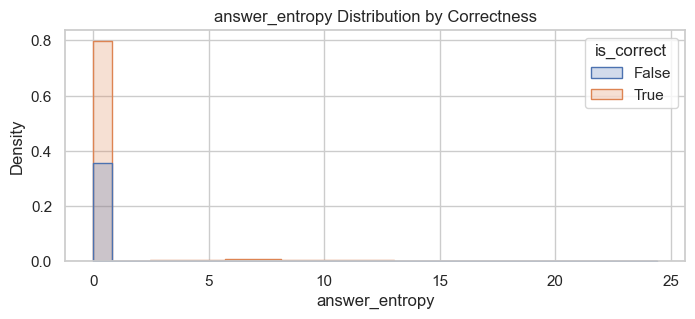

In [14]:
features = ['mean_entropy','max_entropy','mean_margin','max_margin','thinking_entropy','answer_entropy']
for feat in features:
    plt.figure(figsize=(8,3))
    sns.histplot(df, x=feat, hue='is_correct', bins=30, stat='density', element='step')
    plt.title(f"{feat} Distribution by Correctness")
    plt.show()

In [15]:
def norm(series):
    return 1 - (series - series.min()) / (series.max() - series.min())

In [16]:
results = []
for feat in features:
    mask = df[feat].notna()
    y_true = df.loc[mask,'is_correct']
    y_score = norm(df.loc[mask, feat])
    roc = roc_auc_score(y_true, y_score)
    gini = abs(2*roc - 1)
    results.append({'feature': feat, 'roc_auc': roc, 'gini': gini})

print(pd.DataFrame(results))

            feature   roc_auc      gini
0      mean_entropy  0.708954  0.417908
1       max_entropy  0.614478  0.228955
2       mean_margin  0.699954  0.399909
3        max_margin  0.533412  0.066825
4  thinking_entropy  0.663190  0.326380
5    answer_entropy  0.384814  0.230373


In [17]:
cats = df['category'].unique()
roc_by_cat = []
for cat in cats:
    sub = df[df['category']==cat]
    if len(sub) < 20: continue
    for feat in features:
        mask = sub[feat].notna()
        r = roc_auc_score(sub.loc[mask,'is_correct'], norm(sub.loc[mask,feat]))
        roc_by_cat.append({'category': cat, 'feature': feat, 'roc_auc': r})

pd.DataFrame(roc_by_cat).pivot(index='category', columns='feature', values='roc_auc')

feature,answer_entropy,max_entropy,max_margin,mean_entropy,mean_margin,thinking_entropy
category,,,,,,
biology,0.297030,0.623461,0.550906,0.639558,0.628142,0.684102
business,0.294175,0.594008,0.522382,0.651857,0.660161,0.559448
chemistry,0.263578,0.620198,0.537185,0.616114,0.595959,0.632038
computer science,0.359373,0.551815,0.527295,0.621480,0.636884,0.574171
economics,0.368884,0.633915,0.539062,0.659676,0.632845,0.699577
engineering,0.326063,0.519096,0.531073,0.704892,0.712348,0.603627
health,0.420399,0.626760,0.516576,0.660776,0.649255,0.677696
history,0.424381,0.601198,0.536693,0.627070,0.628969,0.663260
law,0.467912,0.562552,0.513500,0.554813,0.548923,0.636998
